## Gait data (Pose keypoints)

In [1]:
%matplotlib widget
import json, sys
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.spatial.distance import pdist, squareform

sys.path.insert(0, str(Path(".").resolve()))
import vineyard_ext  # C++ extension: GUDHI chain matrix with vine swaps

POSE_DIR = Path("dataset_samples/pose")
MAX_EDGE_LENGTH = 300  # pixels — only include edges shorter than this
MIN_VINE_FRAMES = 5    # vine must appear in at least this many frames

KEYPOINT_NAMES = [
    "nose", "l_eye", "r_eye", "l_ear", "r_ear",
    "l_shoulder", "r_shoulder", "l_elbow", "r_elbow",
    "l_wrist", "r_wrist", "l_hip", "r_hip",
    "l_knee", "r_knee", "l_ankle", "r_ankle",
]
N_KP = len(KEYPOINT_NAMES)  # 17


def load_pose_frames(json_path):
    """Load AlphaPose JSON, return list of (frame_idx, 17x2 array) for valid frames."""
    data = json.loads(json_path.read_text())
    frames = []
    for entry in data:
        if entry["joints"] is None:
            continue
        pts = np.array([[entry["joints"][k]["x"], entry["joints"][k]["y"]] for k in KEYPOINT_NAMES])
        frames.append((entry["frame"], pts))
    return frames


def build_rips_simplices(n_points, max_edge_length, all_dist_matrices):
    """Build the union Rips complex (up to dim 2) over all frames.

    Returns (simplex_list, filtration_per_frame) ready for vineyard_ext.
    """
    simplices = [[i] for i in range(n_points)]

    # Union of edges across all frames
    edge_set = set()
    for D in all_dist_matrices:
        for i in range(n_points):
            for j in range(i + 1, n_points):
                if D[i, j] <= max_edge_length:
                    edge_set.add((i, j))
    edges = sorted(edge_set)
    for i, j in edges:
        simplices.append([i, j])

    # Triangles: add [i,j,k] if all three edges exist in the union
    edge_set_frozen = set(edges)
    for i, j in edges:
        for k in range(n_points):
            if k <= j:
                continue
            if (i, k) in edge_set_frozen and (j, k) in edge_set_frozen:
                simplices.append([i, j, k])

    # Filtration values per frame
    filtration_per_frame = []
    for D in all_dist_matrices:
        filt = [0.0] * len(simplices)
        for idx, sx in enumerate(simplices):
            if len(sx) == 2:
                filt[idx] = D[sx[0], sx[1]]
            elif len(sx) == 3:
                filt[idx] = max(D[sx[0], sx[1]], D[sx[0], sx[2]], D[sx[1], sx[2]])
        filtration_per_frame.append(filt)

    return simplices, filtration_per_frame


def extract_vines(barcodes, frame_indices, min_frames):
    """Convert per-frame barcodes into vines (tracked persistence pairs).

    The vine swap algorithm preserves bar identity across frames:
    bar i in the barcode at frame t corresponds to bar i at frame t+1.
    """
    if not barcodes:
        return [], []

    n_bars = len(barcodes[0])
    vines_h0, vines_h1 = [], []

    for bar_idx in range(n_bars):
        vine = []
        dim = None
        for frame_i, bc in enumerate(barcodes):
            if bar_idx >= len(bc):
                continue
            d, b, dth = bc[bar_idx]
            dim = d
            if np.isinf(dth):
                continue  # skip essential features
            vine.append((frame_indices[frame_i], b, dth))

        if len(vine) >= min_frames and dim is not None:
            if dim == 0:
                vines_h0.append(vine)
            elif dim == 1:
                vines_h1.append(vine)

    return vines_h0, vines_h1


def draw_vineyard_lines(ax, vines, frame_indices, color, alpha=0.6):
    if not vines:
        return
    t_min, t_max = min(frame_indices), max(frame_indices)
    t_range = t_max - t_min if t_max > t_min else 1

    for vine in vines:
        vine_sorted = sorted(vine, key=lambda x: x[0])
        births = [v[1] for v in vine_sorted]
        deaths = [v[2] for v in vine_sorted]
        times = [(v[0] - t_min) / t_range for v in vine_sorted]
        ax.plot(births, deaths, times, color=color, alpha=alpha, linewidth=0.8)


def visualize_pose_vineyard(json_path):
    frames = load_pose_frames(json_path)
    if len(frames) < 2:
        return

    trial_name = json_path.stem
    condition = json_path.parent.name
    patient = json_path.parent.parent.name
    label = f"{patient}/{condition}/{trial_name}"
    print(f"  Processing {len(frames)} frames for {label}...")

    frame_indices = [f[0] for f in frames]
    all_pts = [f[1] for f in frames]
    all_dist = [squareform(pdist(pts)) for pts in all_pts]

    # Build union Rips complex
    simplices, filtration_per_frame = build_rips_simplices(N_KP, MAX_EDGE_LENGTH, all_dist)
    print(f"    Complex: {N_KP} vertices, {len(simplices)} simplices, {len(frames)} frames")

    # Compute vineyard via C++ chain matrix with vine swaps
    barcodes = vineyard_ext.compute_vineyard(simplices, filtration_per_frame)

    # Extract vines
    vines_h0, vines_h1 = extract_vines(barcodes, frame_indices, MIN_VINE_FRAMES)
    print(f"    H0 vines: {len(vines_h0)}, H1 vines: {len(vines_h1)}")

    # Plot
    fig = plt.figure(figsize=(16, 7))
    fig.suptitle(f'Vineyard (Chain Matrix) — {label}', fontsize=13, fontweight='bold')

    for subplot_idx, (dim_label, vines, color) in enumerate([
        ('H0 (Components)', vines_h0, 'steelblue'),
        ('H1 (Loops)',      vines_h1, 'tomato'),
    ]):
        ax = fig.add_subplot(1, 2, subplot_idx + 1, projection='3d')
        draw_vineyard_lines(ax, vines, frame_indices, color)

        all_vals = []
        for vine in vines:
            for _, b, d in vine:
                all_vals.extend([b, d])
        if all_vals:
            vmin, vmax = min(all_vals), max(all_vals)
            grid = np.linspace(vmin, vmax, 10)
            B, T = np.meshgrid(grid, np.linspace(0, 1, 10))
            ax.plot_surface(B, B, T, alpha=0.07, color='gray')

        ax.set_xlabel("Birth", fontsize=9, labelpad=6)
        ax.set_ylabel("Death", fontsize=9, labelpad=6)
        ax.set_zlabel("Time", fontsize=9, labelpad=6)
        ax.set_title(dim_label, fontsize=11)
        ax.tick_params(labelsize=7)
        ax.view_init(elev=25, azim=-55)

    plt.tight_layout()
    plt.show()
    print(f"  Done: {label}")

  Processing 91 frames for PA000/FGS/WJ_1_AlphaPose...
    Complex: 17 vertices, 833 simplices, 91 frames
    H0 vines: 16, H1 vines: 120


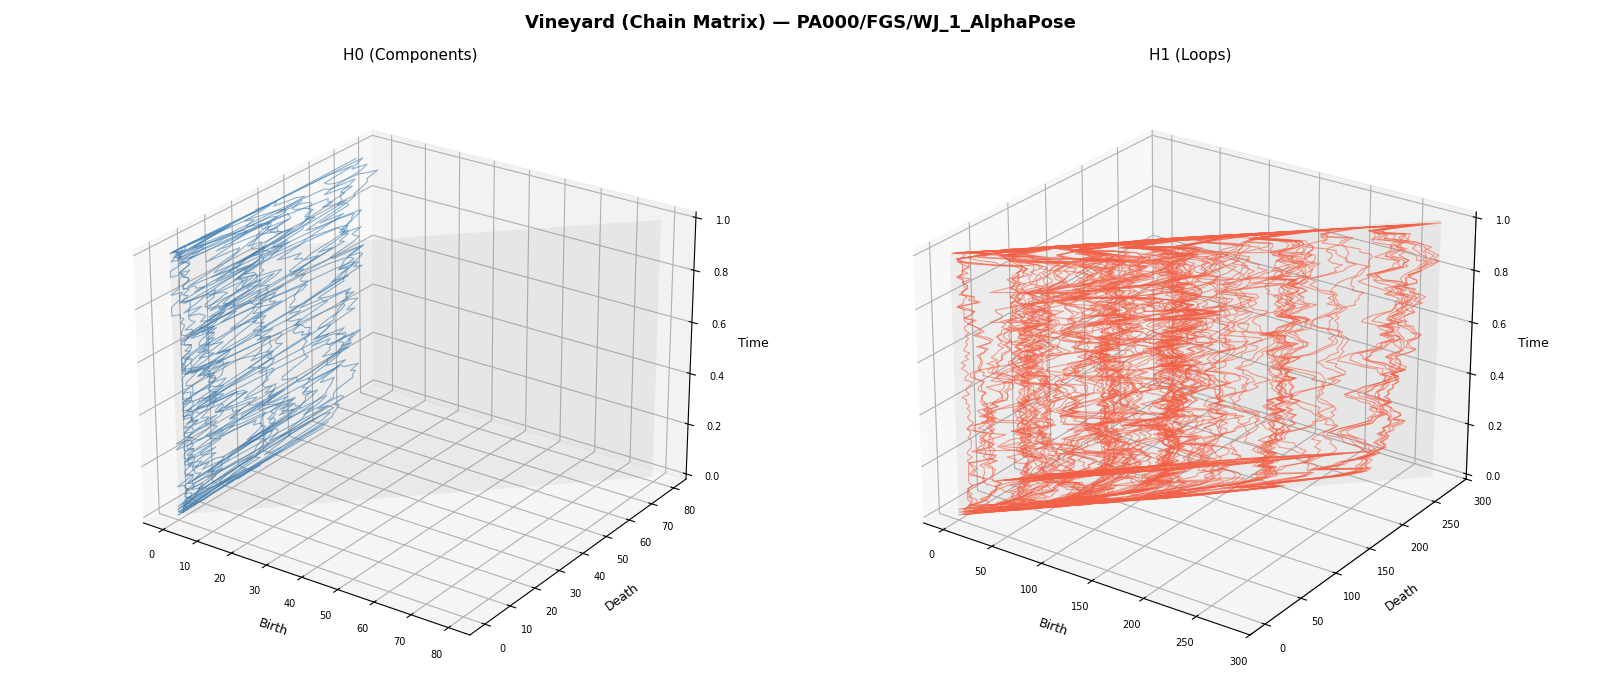

  Done: PA000/FGS/WJ_1_AlphaPose
  Processing 90 frames for PA000/FGS/WJ_2_AlphaPose...
    Complex: 17 vertices, 833 simplices, 90 frames
    H0 vines: 16, H1 vines: 120


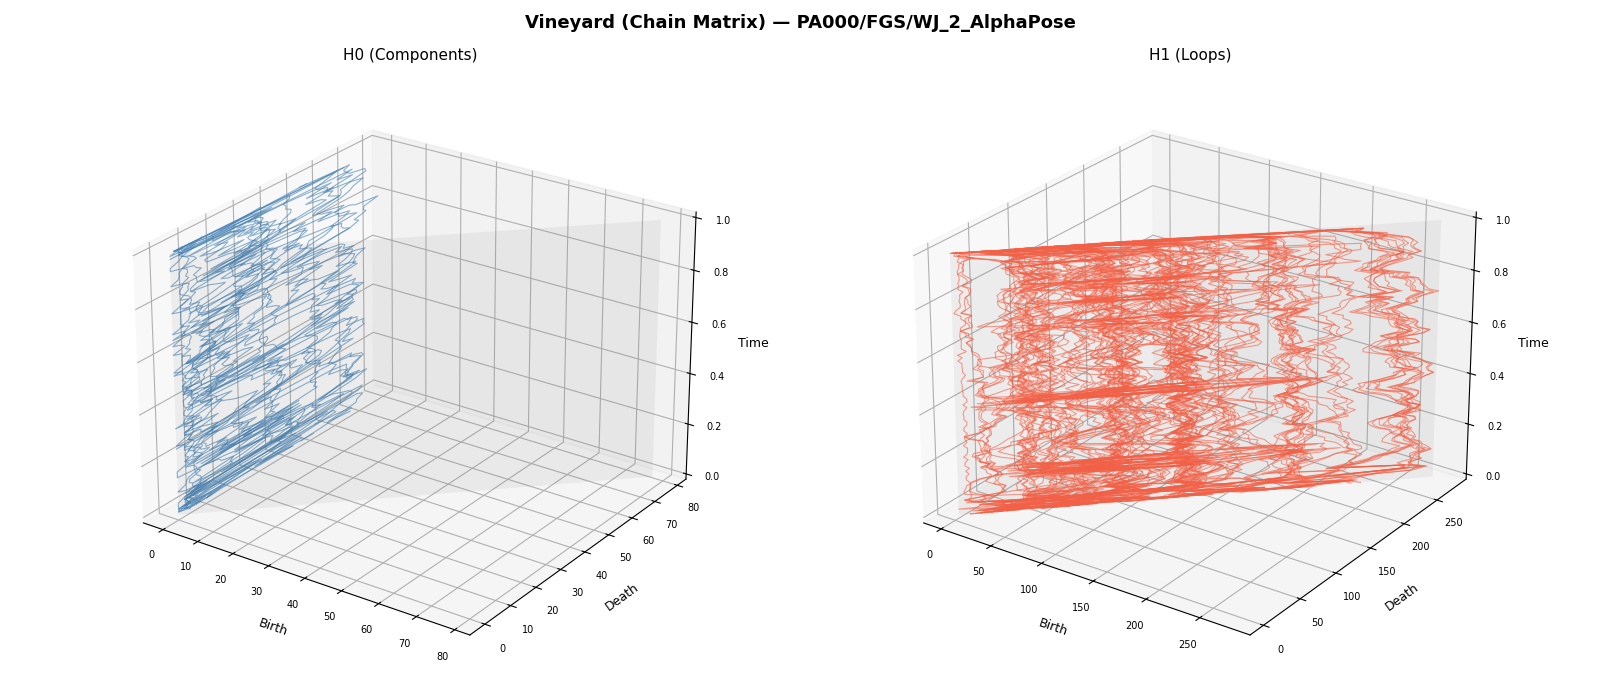

  Done: PA000/FGS/WJ_2_AlphaPose


In [3]:
for patient_dir in sorted(POSE_DIR.iterdir()):
    if not patient_dir.is_dir():
        continue
    for json_path in sorted(patient_dir.rglob("*_AlphaPose.json"))[:2]:
        visualize_pose_vineyard(json_path)
        # break

## Chaotic pendulum

In [6]:
"""
Chaos Pendulum - Fast Analytical Simulation
=============================================
Pivoting bar + two triple pendulums.
Uses explicit Lagrangian with analytical derivatives via a simplified
energy-based approach with numerical mass matrix (computed efficiently).
"""

import numpy as np
from scipy.integrate import solve_ivp
import csv
import os

# ─── Parameters ───
g = 9.81
L_bar = 1.5       # half-length
M_bar = 2.0
I_bar = (1/3) * M_bar * (2*L_bar)**2

L1, L2, L3 = 1.0, 1.0, 1.0
m1, m2, m3 = 1.0, 1.5, 0.8
damping = 0.05

T_total = 30.0
dt = 0.01
t_eval = np.arange(0, T_total, dt)

# Initial conditions
y0 = np.array([
    0.0, 0.15, 0.0, -0.1, -0.1, 0.05, 0.0,  # angles
    2.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,       # angular velocities
])

def compute_pos(q):
    """Compute positions of 6 mass points + bar endpoints. Returns (8,2)."""
    phi, th1L, th2L, th3L, th1R, th2R, th3R = q
    
    cp, sp = np.cos(phi), np.sin(phi)
    
    # Bar endpoints
    xbL, ybL = -L_bar * cp, -L_bar * sp
    xbR, ybR =  L_bar * cp,  L_bar * sp
    
    # Left chain
    s1L, c1L = np.sin(th1L), np.cos(th1L)
    s2L, c2L = np.sin(th2L), np.cos(th2L)
    s3L, c3L = np.sin(th3L), np.cos(th3L)
    
    x1L = xbL + L1*s1L;  y1L = ybL - L1*c1L
    x2L = x1L + L2*s2L;  y2L = y1L - L2*c2L
    x3L = x2L + L3*s3L;  y3L = y2L - L3*c3L
    
    # Right chain
    s1R, c1R = np.sin(th1R), np.cos(th1R)
    s2R, c2R = np.sin(th2R), np.cos(th2R)
    s3R, c3R = np.sin(th3R), np.cos(th3R)
    
    x1R = xbR + L1*s1R;  y1R = ybR - L1*c1R
    x2R = x1R + L2*s2R;  y2R = y1R - L2*c2R
    x3R = x2R + L3*s3R;  y3R = y2R - L3*c3R
    
    return np.array([
        [xbL, ybL], [xbR, ybR],
        [x1L, y1L], [x2L, y2L], [x3L, y3L],
        [x1R, y1R], [x2R, y2R], [x3R, y3R],
    ])


def compute_jacobian(q):
    """
    Analytical Jacobian: d(mass_positions)/d(q).
    Returns J of shape (6, 2, 7) for 6 mass points.
    """
    phi, th1L, th2L, th3L, th1R, th2R, th3R = q
    cp, sp = np.cos(phi), np.sin(phi)
    s1L, c1L = np.sin(th1L), np.cos(th1L)
    s2L, c2L = np.sin(th2L), np.cos(th2L)
    s3L, c3L = np.sin(th3L), np.cos(th3L)
    s1R, c1R = np.sin(th1R), np.cos(th1R)
    s2R, c2R = np.sin(th2R), np.cos(th2R)
    s3R, c3R = np.sin(th3R), np.cos(th3R)
    
    J = np.zeros((6, 2, 7))
    
    # Mass 0: ball1L at (xbL + L1*s1L, ybL - L1*c1L)
    # xbL = -L_bar*cp, ybL = -L_bar*sp
    # dx/dphi = L_bar*sp,  dy/dphi = -L_bar*cp
    # dx/dth1L = L1*c1L,   dy/dth1L = L1*s1L
    J[0, 0, 0] = L_bar*sp;    J[0, 1, 0] = -L_bar*cp
    J[0, 0, 1] = L1*c1L;      J[0, 1, 1] = L1*s1L
    
    # Mass 1: ball2L at (xbL + L1*s1L + L2*s2L, ybL - L1*c1L - L2*c2L)
    J[1, 0, 0] = L_bar*sp;    J[1, 1, 0] = -L_bar*cp
    J[1, 0, 1] = L1*c1L;      J[1, 1, 1] = L1*s1L
    J[1, 0, 2] = L2*c2L;      J[1, 1, 2] = L2*s2L
    
    # Mass 2: ball3L
    J[2, 0, 0] = L_bar*sp;    J[2, 1, 0] = -L_bar*cp
    J[2, 0, 1] = L1*c1L;      J[2, 1, 1] = L1*s1L
    J[2, 0, 2] = L2*c2L;      J[2, 1, 2] = L2*s2L
    J[2, 0, 3] = L3*c3L;      J[2, 1, 3] = L3*s3L
    
    # Mass 3: ball1R at (xbR + L1*s1R, ybR - L1*c1R)
    # xbR = L_bar*cp, ybR = L_bar*sp
    # dx/dphi = -L_bar*sp,  dy/dphi = L_bar*cp
    J[3, 0, 0] = -L_bar*sp;   J[3, 1, 0] = L_bar*cp
    J[3, 0, 4] = L1*c1R;      J[3, 1, 4] = L1*s1R
    
    # Mass 4: ball2R
    J[4, 0, 0] = -L_bar*sp;   J[4, 1, 0] = L_bar*cp
    J[4, 0, 4] = L1*c1R;      J[4, 1, 4] = L1*s1R
    J[4, 0, 5] = L2*c2R;      J[4, 1, 5] = L2*s2R
    
    # Mass 5: ball3R
    J[5, 0, 0] = -L_bar*sp;   J[5, 1, 0] = L_bar*cp
    J[5, 0, 4] = L1*c1R;      J[5, 1, 4] = L1*s1R
    J[5, 0, 5] = L2*c2R;      J[5, 1, 5] = L2*s2R
    J[5, 0, 6] = L3*c3R;      J[5, 1, 6] = L3*s3R
    
    return J


def compute_jacobian_dot(q, dq):
    """
    Time derivative of Jacobian: dJ/dt = sum_k (dJ/dq_k) * dq_k.
    Returns Jdot of shape (6, 2, 7).
    """
    phi, th1L, th2L, th3L, th1R, th2R, th3R = q
    dphi, dth1L, dth2L, dth3L, dth1R, dth2R, dth3R = dq
    
    cp, sp = np.cos(phi), np.sin(phi)
    s1L, c1L = np.sin(th1L), np.cos(th1L)
    s2L, c2L = np.sin(th2L), np.cos(th2L)
    s3L, c3L = np.sin(th3L), np.cos(th3L)
    s1R, c1R = np.sin(th1R), np.cos(th1R)
    s2R, c2R = np.sin(th2R), np.cos(th2R)
    s3R, c3R = np.sin(th3R), np.cos(th3R)
    
    Jd = np.zeros((6, 2, 7))
    
    # d/dt of J entries: chain rule on trig functions
    # For bar terms: d/dt(L_bar*sp) = L_bar*cp*dphi, d/dt(-L_bar*cp) = L_bar*sp*dphi
    
    # Mass 0 (ball1L)
    Jd[0, 0, 0] = L_bar*cp*dphi;     Jd[0, 1, 0] = L_bar*sp*dphi
    Jd[0, 0, 1] = -L1*s1L*dth1L;     Jd[0, 1, 1] = L1*c1L*dth1L
    
    # Mass 1 (ball2L)
    Jd[1, 0, 0] = L_bar*cp*dphi;     Jd[1, 1, 0] = L_bar*sp*dphi
    Jd[1, 0, 1] = -L1*s1L*dth1L;     Jd[1, 1, 1] = L1*c1L*dth1L
    Jd[1, 0, 2] = -L2*s2L*dth2L;     Jd[1, 1, 2] = L2*c2L*dth2L
    
    # Mass 2 (ball3L)
    Jd[2, 0, 0] = L_bar*cp*dphi;     Jd[2, 1, 0] = L_bar*sp*dphi
    Jd[2, 0, 1] = -L1*s1L*dth1L;     Jd[2, 1, 1] = L1*c1L*dth1L
    Jd[2, 0, 2] = -L2*s2L*dth2L;     Jd[2, 1, 2] = L2*c2L*dth2L
    Jd[2, 0, 3] = -L3*s3L*dth3L;     Jd[2, 1, 3] = L3*c3L*dth3L
    
    # Mass 3 (ball1R)
    Jd[3, 0, 0] = -L_bar*cp*dphi;    Jd[3, 1, 0] = -L_bar*sp*dphi
    Jd[3, 0, 4] = -L1*s1R*dth1R;     Jd[3, 1, 4] = L1*c1R*dth1R
    
    # Mass 4 (ball2R)
    Jd[4, 0, 0] = -L_bar*cp*dphi;    Jd[4, 1, 0] = -L_bar*sp*dphi
    Jd[4, 0, 4] = -L1*s1R*dth1R;     Jd[4, 1, 4] = L1*c1R*dth1R
    Jd[4, 0, 5] = -L2*s2R*dth2R;     Jd[4, 1, 5] = L2*c2R*dth2R
    
    # Mass 5 (ball3R)
    Jd[5, 0, 0] = -L_bar*cp*dphi;    Jd[5, 1, 0] = -L_bar*sp*dphi
    Jd[5, 0, 4] = -L1*s1R*dth1R;     Jd[5, 1, 4] = L1*c1R*dth1R
    Jd[5, 0, 5] = -L2*s2R*dth2R;     Jd[5, 1, 5] = L2*c2R*dth2R
    Jd[5, 0, 6] = -L3*s3R*dth3R;     Jd[5, 1, 6] = L3*c3R*dth3R
    
    return Jd


masses = np.array([m1, m2, m3, m1, m2, m3])
gvec = np.array([0, -g])  # gravity vector (y points up in math, down in display... let's be consistent)
# Actually in our coords, y is "up" in the math sense but we draw it inverted.
# Gravity pulls things in -y direction.
# The potential energy gradient for mass i: dV/dq_j = m_i * g * dyi/dq_j
# Force = -dV/dq = -m_i * g * (dy_i/dq_j) ... but gravity is in -y direction
# So gravitational generalized force Q_j = sum_i m_i * (-g) * J_i[1, j]
# Wait: F_grav on mass i = [0, -m_i*g]. Generalized force = J_i^T @ F_i
# Q = sum_i J_i^T @ [0, -m_i*g]

def derivs(t, y):
    n = 7
    q = y[:n]
    dq = y[n:]
    
    J = compute_jacobian(q)      # (6, 2, 7)
    Jd = compute_jacobian_dot(q, dq)  # (6, 2, 7)
    
    # Mass matrix: M = I_bar*e0e0^T + sum_i m_i * J_i^T @ J_i
    M = np.zeros((n, n))
    M[0, 0] = I_bar
    for i in range(6):
        Ji = J[i]  # (2, 7)
        M += masses[i] * (Ji.T @ Ji)
    
    # Gravitational generalized forces
    Q_grav = np.zeros(n)
    for i in range(6):
        Ji = J[i]  # (2, 7)
        F_i = np.array([0.0, -masses[i] * g])
        Q_grav += Ji.T @ F_i
    
    # Coriolis/centrifugal: C*dq where the full eq is M*ddq + C*dq = Q
    # C*dq = sum_i m_i * J_i^T @ Jd_i @ dq
    Cdq = np.zeros(n)
    for i in range(6):
        Ji = J[i]
        Jdi = Jd[i]
        vel_i = Jdi @ dq  # (2,) = centripetal acceleration contribution
        Cdq += masses[i] * (Ji.T @ vel_i)
    
    # M*ddq = Q_grav - Cdq - damping*dq
    rhs = Q_grav - Cdq - damping * dq
    ddq = np.linalg.solve(M, rhs)
    
    return np.concatenate([dq, ddq])


print("Running simulation...")
sol = solve_ivp(derivs, [0, T_total], y0, t_eval=t_eval,
                method='RK45', rtol=1e-8, atol=1e-10, max_step=0.005)

print(f"Integration complete: {sol.t.shape[0]} time steps, success={sol.success}")

# ─── Compute Point Cloud ───
n_steps = sol.t.shape[0]
point_cloud = np.zeros((n_steps, 7, 2))  # pivot + 6 balls
bar_endpoints = np.zeros((n_steps, 2, 2))

for i in range(n_steps):
    q = sol.y[:7, i]
    p = compute_pos(q)
    # p: 0=barL, 1=barR, 2=b1L, 3=b2L, 4=b3L, 5=b1R, 6=b2R, 7=b3R
    point_cloud[i, 0] = [0.0, 0.0]  # pivot
    point_cloud[i, 1] = p[2]  # ball1L
    point_cloud[i, 2] = p[3]  # ball2L
    point_cloud[i, 3] = p[4]  # ball3L
    point_cloud[i, 4] = p[5]  # ball1R
    point_cloud[i, 5] = p[6]  # ball2R
    point_cloud[i, 6] = p[7]  # ball3R
    bar_endpoints[i, 0] = p[0]  # barL
    bar_endpoints[i, 1] = p[1]  # barR

# ─── Save CSV ───
output_dir = "./"
csv_path = os.path.join(output_dir, "chaos_pendulum_pointcloud.csv")

with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'time',
        'pivot_x', 'pivot_y',
        'ball1L_x', 'ball1L_y', 'ball2L_x', 'ball2L_y', 'ball3L_x', 'ball3L_y',
        'ball1R_x', 'ball1R_y', 'ball2R_x', 'ball2R_y', 'ball3R_x', 'ball3R_y',
        'barL_x', 'barL_y', 'barR_x', 'barR_y',
    ])
    for i in range(n_steps):
        row = [f"{sol.t[i]:.4f}"]
        for j in range(7):
            row.extend([f"{point_cloud[i,j,0]:.6f}", f"{point_cloud[i,j,1]:.6f}"])
        row.extend([
            f"{bar_endpoints[i,0,0]:.6f}", f"{bar_endpoints[i,0,1]:.6f}",
            f"{bar_endpoints[i,1,0]:.6f}", f"{bar_endpoints[i,1,1]:.6f}",
        ])
        writer.writerow(row)

print(f"CSV saved: {csv_path} ({n_steps} rows)")

# Save numpy arrays
np.save(os.path.join(output_dir, "chaos_pendulum_pointcloud.npy"), point_cloud)
np.save(os.path.join(output_dir, "chaos_pendulum_times.npy"), sol.t)
np.save(os.path.join(output_dir, "chaos_pendulum_bar.npy"), bar_endpoints)
print("NumPy arrays saved.")
print(f"Point cloud shape: {point_cloud.shape}  (timesteps, points, xy)")

Running simulation...
Integration complete: 3000 time steps, success=True
CSV saved: ./chaos_pendulum_pointcloud.csv (3000 rows)
NumPy arrays saved.
Point cloud shape: (3000, 7, 2)  (timesteps, points, xy)


In [7]:
"""
Generate video of the chaos pendulum simulation.

Outputs:
  - MP4 if FFmpeg is installed
  - GIF fallback via Pillow (no external dependencies needed)

Usage: python render_video.py
  Expects .npy files in the same directory as this script.
"""

import os
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ─── Load data (same directory as script) ───
script_dir = "./"
point_cloud = np.load(os.path.join(script_dir, "chaos_pendulum_pointcloud.npy"))
times = np.load(os.path.join(script_dir, "chaos_pendulum_times.npy"))
bar_ep = np.load(os.path.join(script_dir, "chaos_pendulum_bar.npy"))

n_steps = point_cloud.shape[0]

# ─── Setup Figure ───
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#0d1117')
ax.set_facecolor('#0d1117')
ax.set_xlim(-6, 6)
ax.set_ylim(-7, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.1, color='#30363d')
ax.set_xlabel('x (m)', color='#8b949e', fontsize=11)
ax.set_ylabel('y (m)', color='#8b949e', fontsize=11)
ax.tick_params(colors='#484f58')
for spine in ax.spines.values():
    spine.set_color('#21262d')

title_text = ax.set_title('Chaos Pendulum — t = 0.00 s', color='#e6edf3',
                           fontsize=15, fontweight='bold', pad=15)

# Colors
cL = ['#f97583', '#f97583', '#f97583']  # left chain (red tones)
cR = ['#79c0ff', '#79c0ff', '#79c0ff']  # right chain (blue tones)
ball_sz = [8, 11, 7]

# Trail data
trail_len = 200
trails = {i: ([], []) for i in range(6)}  # 6 balls

# Plot elements
bar_line, = ax.plot([], [], '-', color='#c9d1d9', linewidth=3.5, solid_capstyle='round', zorder=5)
pivot_dot, = ax.plot([], [], 'o', color='#f0c000', markersize=14, zorder=10,
                      markeredgecolor='#b08800', markeredgewidth=1.5)

arm_lines = []
ball_dots = []
trail_lines = []

for j in range(3):
    arm_lines.append(ax.plot([], [], '-', color=cL[j], linewidth=2, alpha=0.7, zorder=3)[0])
    ball_dots.append(ax.plot([], [], 'o', color=cL[j], markersize=ball_sz[j],
                              markeredgecolor='white', markeredgewidth=0.5, zorder=8)[0])
    trail_lines.append(ax.plot([], [], '-', color=cL[j], linewidth=0.8, alpha=0.35, zorder=1)[0])

for j in range(3):
    arm_lines.append(ax.plot([], [], '-', color=cR[j], linewidth=2, alpha=0.7, zorder=3)[0])
    ball_dots.append(ax.plot([], [], 'o', color=cR[j], markersize=ball_sz[j],
                              markeredgecolor='white', markeredgewidth=0.5, zorder=8)[0])
    trail_lines.append(ax.plot([], [], '-', color=cR[j], linewidth=0.8, alpha=0.35, zorder=1)[0])

# Labels
ax.text(0.02, 0.98, 'Pivoting bar + 2x triple pendulum\n7 DOF chaotic system',
        transform=ax.transAxes, color='#8b949e', fontsize=9, va='top',
        fontfamily='monospace', alpha=0.7)

# Subsample: render every 3rd frame -> ~33 fps from 100Hz data
step = 3
frame_indices = list(range(0, n_steps, step))
n_frames = len(frame_indices)
print(f"Rendering {n_frames} frames...")


def update(frame_num):
    i = frame_indices[frame_num]
    t = times[i]
    title_text.set_text(f'Chaos Pendulum — t = {t:.2f} s')

    bL = bar_ep[i, 0]
    bR = bar_ep[i, 1]
    bar_line.set_data([bL[0], bR[0]], [bL[1], bR[1]])
    pivot_dot.set_data([0], [0])

    # Left chain: bar_left -> b1L -> b2L -> b3L
    anchors_L = [bL, point_cloud[i, 1], point_cloud[i, 2], point_cloud[i, 3]]
    for j in range(3):
        p0, p1 = anchors_L[j], anchors_L[j + 1]
        arm_lines[j].set_data([p0[0], p1[0]], [p0[1], p1[1]])
        ball_dots[j].set_data([p1[0]], [p1[1]])
        trails[j][0].append(p1[0]); trails[j][1].append(p1[1])
        if len(trails[j][0]) > trail_len:
            trails[j] = (trails[j][0][-trail_len:], trails[j][1][-trail_len:])
        trail_lines[j].set_data(trails[j][0], trails[j][1])

    # Right chain: bar_right -> b1R -> b2R -> b3R
    anchors_R = [bR, point_cloud[i, 4], point_cloud[i, 5], point_cloud[i, 6]]
    for j in range(3):
        p0, p1 = anchors_R[j], anchors_R[j + 1]
        arm_lines[3 + j].set_data([p0[0], p1[0]], [p0[1], p1[1]])
        ball_dots[3 + j].set_data([p1[0]], [p1[1]])
        trails[3 + j][0].append(p1[0]); trails[3 + j][1].append(p1[1])
        if len(trails[3 + j][0]) > trail_len:
            trails[3 + j] = (trails[3 + j][0][-trail_len:], trails[3 + j][1][-trail_len:])
        trail_lines[3 + j].set_data(trails[3 + j][0], trails[3 + j][1])

    return []


anim = FuncAnimation(fig, update, frames=n_frames, interval=30, blit=True)

# ─── Save: try MP4 (FFmpeg) first, fall back to GIF (Pillow) ───
try:
    from matplotlib.animation import FFMpegWriter
    video_path = os.path.join(script_dir, "chaos_pendulum.mp4")
    writer = FFMpegWriter(fps=33, metadata=dict(title='Chaos Pendulum'), bitrate=4000)
    anim.save(video_path, writer=writer, dpi=100)
    print(f"MP4 saved: {video_path}")
except (FileNotFoundError, RuntimeError) as e:
    print(f"FFmpeg not available ({e}), falling back to GIF via Pillow...")
    from matplotlib.animation import PillowWriter
    video_path = os.path.join(script_dir, "chaos_pendulum.gif")
    writer = PillowWriter(fps=33)
    anim.save(video_path, writer=writer, dpi=80)
    print(f"GIF saved: {video_path}")

plt.close()
print("Done!")

Rendering 1000 frames...
FFmpeg not available ([WinError 2] The system cannot find the file specified), falling back to GIF via Pillow...
GIF saved: ./chaos_pendulum.gif
Done!
